# TP1 — From Theory to Practice: MLP with PyTorch

---

## Objectives

By the end of this session, you will be able to:
1. Manipulate **PyTorch tensors and automatic differentiation** as the computational substrate of deep learning
2. Implement a **complete supervised training pipeline** from data loading to evaluation
3. Design and interpret **controlled experiments** comparing optimisation strategies and regularisation techniques

## Prerequisites (CM1–CM2)
- **CM1**: MLP architecture, activation functions, backpropagation, vanishing/exploding gradients
- **CM2**: PyTorch training pipeline — DataLoader, nn.Module, optimisers, Dropout, Batch Normalisation

## Deliverables
**Send your GitHub repository link to [xchang3@slb.com](mailto:xchang3@slb.com) and submit on GitHub before the deadline.**
```
your-repo/
├── tp1-pytorch-mlp.ipynb   ← all cells executed top-to-bottom, outputs visible
└── report.pdf              ← 1–2 pages, maximum 2 pages
```

**Deadline**: **23:59, September 24th**

This TP is completed in pairs (binôme). Submit one GitHub repository per pair.

Your PDF report should answer the following sections:
1. **Part 1 — Baseline Model**: answer the four questions at the end of Part 1
2. **Experiment 1**: fill in the Results and Analysis section
3. **Experiment 2A**: fill in the Results and Analysis section
4. **Experiment 2B**: fill in the Results and Analysis section
5. **Experiment 3**: fill in the Results and Analysis section

Results must be discussed analytically — cite specific numbers, reference figures by their titles, and connect observations to theory from CM1/CM2.

## Session Structure

| Part | Content |
|------|---------|
| 0 · Tensor Warmup | Core tensor operations and automatic differentiation |
| 1 · Training Pipeline | End-to-end MLP implementation on Fashion-MNIST |
| 2 · Experimental Analysis | Student-designed ablation studies |

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ── Device setup ──────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'PyTorch version: {torch.__version__}')

# num_workers: multiprocessing helps on GPU; set to 0 on CPU to avoid fork issues
NUM_WORKERS = 2 if device.type == 'cuda' else 0

Using device: cpu
PyTorch version: 2.11.0+cpu


---
## Part 0 — Tensor Warmup

This section introduces PyTorch's core primitives — tensors and automatic differentiation — which underpin every operation in a deep learning pipeline.

### Exercise 0.1 — Tensor Operations

A neural network forward pass is a composition of matrix multiplications and element-wise non-linearities. The following exercise traces one such step explicitly in PyTorch. Complete the `# TODO` sections.

In [ ]:
# (a) A mini-batch of 4 28×28 images, each flattened to 784 pixels
batch = torch.zeros(4, 784)
print(f'Batch shape: {batch.shape}')

# (b) Weight matrix for a Linear layer: 784 inputs → 128 outputs
W = torch.randn(784,128)

# (c) Linear transformation (4, 784) * (784, 128) → (4, 128)
# TODO: Compute the matrix product — result should have shape [4, 128]
output = batch @ W
if output is not None:
    print(f'Linear output shape: {output.shape}')  # Expected: torch.Size([4, 128])

# (d) Apply ReLU activation  (recall CM1: why ReLU instead of Sigmoid?)
# TODO: Apply F.relu() to output
activated = torch.relu(output)
if activated is not None:
    print(f'After ReLU — min value : {activated.min():.3f}')  # Must be 0.0
    print(f'           — #negatives: {(activated < 0).sum().item()}')  # Must be 0

Batch shape: torch.Size([4, 784])
Linear output shape: torch.Size([4, 128])
After ReLU — min value : 0.000
           — #negatives: 0


### Exercise 0.2 — Automatic Differentiation

PyTorch implements reverse-mode automatic differentiation through a dynamically constructed computation graph. This mirrors the backpropagation derivation, but is executed automatically by the framework.

**Before running the following cell**, derive $\frac{dL}{dw}$ analytically:

$$L = (wx - y)^2, \quad x = 2,\; y = 3,\; w = 1$$

$$\frac{dL}{dw} = 2(wx - y) \cdot x = 2(1 \cdot 2 - 3) \cdot 2 = -4$$

Record your result, then verify against PyTorch's computed gradient.

Complete the `# TODO` sections.

In [6]:
x = torch.tensor(2.0)
y = torch.tensor(3.0)
w = torch.tensor(1.0, requires_grad=True)  # requires_grad=True: PyTorch will track this

# Forward pass
pred = w * x            # = 2.0
loss = (pred - y) ** 2  # = (2 - 3)^2 = 1.0

print(f'Prediction: {pred.item():.1f}')
print(f'Loss:       {loss.item():.1f}')

# Write your manual answer before running the next cell
my_gradient = (2 * (w * x - y) * x).item() # TODO: replace with your computed dL/dw
if my_gradient is not None:
    print(f'My manual dL/dw: {my_gradient}')

Prediction: 2.0
Loss:       1.0
My manual dL/dw: -4.0


In [ ]:
# PyTorch computes the gradient via reverse-mode autodiff
# call loss.backward() to trigger the backward pass
loss.backward()
print(f'Analytical dL/dw:  {my_gradient}')
print(f'PyTorch  dL/dw:    {w.grad.item():.1f}')

# One gradient-descent update (lr = 0.1)
# TODO: compute new_w = w - lr * gradient  (use w.grad, lr = 0.1)
new_w = w - 0.1* w.grad
print(f'Gradient step (lr=0.1): w = {w.item():.1f} -> {new_w:.2f}')
print(f'Updated prediction: {new_w * x.item():.2f}   (target: {y.item():.1f})')

Analytical dL/dw:  -4.0
PyTorch  dL/dw:    -4.0
Gradient step (lr=0.1): w = 1.0 -> 1.40
Updated prediction: 2.80   (target: 3.0


---
## Part 1 — Training Pipeline

In this section, we will implement manually a complete MLP training pipeline step by step on Fashion-MNIST, following the five-step framework introduced in CM2:

**Data Preparation → Model Architecture → Training → Diagnosis → Regularisation**

Complete the `# TODO` sections. All other code is provided; study each block before executing it.

### 1.1 — Dataset and Task

**What we're building**: a classifier that reads a 28×28 grayscale image of a clothing item and predicts which of 10 categories it belongs to.

#### The Dataset: Fashion-MNIST

Fashion-MNIST was created by Zalando Research as a drop-in replacement for the classic MNIST digit dataset. While MNIST (handwritten digits) has become too easy for modern models, Fashion-MNIST poses a more realistic challenge: clothing categories share visual structure (e.g. T-shirts and shirts look similar), making classification harder. It has become a standard benchmark for evaluating simple architectures.

| Property | Value |
|----------|-------|
| Image size | 28×28 pixels, grayscale |
| Input dimension | **784 features** (after flattening) |
| Classes | 10 clothing categories |
| Train set | 60,000 images |
| Test set | 10,000 images |
| Our split | 48,000 train / 12,000 val / 10,000 test |

The 10 classes: `T-shirt/top · Trouser · Pullover · Dress · Coat · Sandal · Shirt · Sneaker · Bag · Ankle boot`


In [8]:
# ── 1.1  Load Fashion-MNIST ───────────────────────────────────────────────────

FASHION_CLASSES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot'
]

# Preprocessing pipeline applied to every image:
#   ToTensor()   — converts PIL image [0,255] to float tensor [0,1], shape (1,28,28)
#   Normalize()  — standardises to zero mean and unit variance (channel-wise)
#                  values: mean=0.2860, std=0.3530 (pre-computed for Fashion-MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# Download the dataset (first run only; cached to ./data afterwards)
full_train = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Split the 60k training set into 80% train / 20% validation.
# The validation set monitors generalisation during training;
# In a standard DL workflow, the test set is reserved for final evaluation. In this TP, test accuracy is also displayed for pedagogical comparison.
n_val = int(0.2 * len(full_train))
train_set, val_set = random_split(
    full_train, [len(full_train) - n_val, n_val],
    generator=torch.Generator().manual_seed(42)  # fixed seed → reproducible split
)

# DataLoader handles batching, shuffling, and parallel data loading.
#   batch_size  — number of samples per gradient update
#   shuffle     — randomise order each epoch (training only)
#   num_workers — background processes for loading (0 on CPU to avoid fork issues)
#   pin_memory  — speeds up CPU→GPU transfer when a GPU is available
BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

print(f'Train: {len(train_set):,} | Val: {len(val_set):,} | Test: {len(test_set):,}')

images, labels = next(iter(train_loader))
print(f'Batch  — images: {images.shape}  labels: {labels.shape}')
print(f'Single image shape: {images[0].shape}  =>  flattened: {images[0].numel()} features')

Train: 48,000 | Val: 12,000 | Test: 10,000
Batch  — images: torch.Size([64, 1, 28, 28])  labels: torch.Size([64])
Single image shape: torch.Size([1, 28, 28])  =>  flattened: 784 features


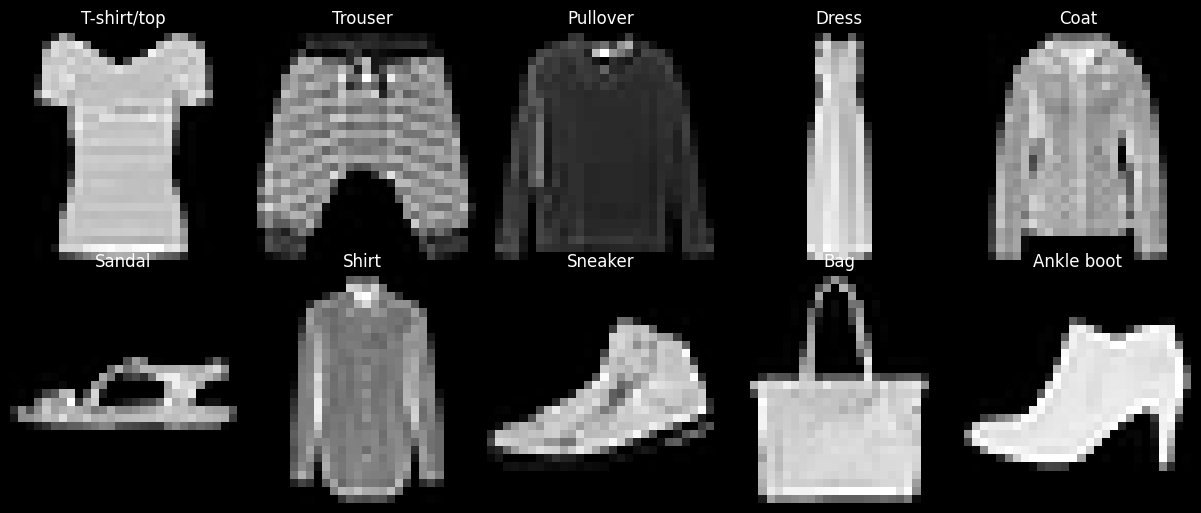

In [9]:
# Collect one representative image per class from the training set.
# We iterate through batches until we have found at least one example of each of the 10 classes.
_samples = {}
for _imgs, _lbls in train_loader:
    for _img, _lbl in zip(_imgs, _lbls):
        lbl = _lbl.item()
        if lbl not in _samples:
            # Un-normalise for display: reverse Normalize(mean, std) → pixel values in [0,1]
            _samples[lbl] = (_img.squeeze().numpy() * 0.353 + 0.286).clip(0, 1)
        if len(_samples) == 10:
            break
    if len(_samples) == 10:
        break

# Display the 10 classes in a 2×5 grid
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.patch.set_facecolor('black')
for i, ax in enumerate(axes.flat):
    ax.imshow(_samples[i], cmap='gray')
    ax.set_title(FASHION_CLASSES[i], color='white', fontsize=12, pad=7)
    ax.axis('off')
    ax.set_facecolor('black')
plt.tight_layout(pad=0.5)
plt.show()

del _samples, _imgs, _lbls, _img, _lbl  # free memory

### 1.2 — Model Architecture

The architecture you will implement:

```
Input (784)  →  Hidden 1 (256, ReLU)  →  Hidden 2 (128, ReLU)  →  Output (10 logits)
```

The `hidden_sizes` parameter controls depth — `[256, 128]` gives 2 hidden layers, `[512, 256, 128]` gives 3. This flexibility is used throughout Part 2.

Each hidden block follows this standard ordering (CM2):

```
nn.Linear  →  [nn.BatchNorm1d]  →  nn.ReLU  →  [nn.Dropout]
```

**What you need to do** (complete the `# TODO` lines in the cell below):
1. Inside the `for` loop — for each hidden layer:
   - Add a `nn.Linear` layer
   - Add `nn.BatchNorm1d` if `use_batchnorm` is True
   - Add the activation function
   - Add `nn.Dropout` if `dropout_rate > 0`
   - Update `in_dim` for the next iteration
2. After the loop — add the output projection `nn.Linear(???, ???)`

> `forward()` is already implemented — `x.view` flattens the image, then `self.net` runs the full pipeline.

In [10]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=[256, 128], dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        in_dim = 784 #input layer dimension

        for h in hidden_sizes: # h is hideen layer size
            # TODO: Add linear layer. Use nn.Linear(in_features, out_features)
            layers.append(nn.Linear(in_dim, h))

            if use_batchnorm:
                # TODO: Add Batch Normalization. nn.BatchNorm1d normalises each feature independently using statistics computed across the mini-batch. How many features does the preceding Linear layer output?
                layers.append(nn.BatchNorm1d(h)) 

            # TODO: Add activation function. (CM1: what property makes it suitable for deep ReLU networks?)
            layers.append(nn.ReLU())
                          
            if dropout_rate > 0 and dropout_rate < 1:
                # TODO: Add Dropout layer. Dropout takes a probability p in [0, 1]
                layers.append(nn.Dropout(dropout_rate))

            # TODO: after this block, the feature dimension has changed, update in_dim so the next iteration uses the correct input size
            in_dim = h

        # ── Output: no activation (CrossEntropyLoss handles softmax internally) ──
        # TODO: For Output layer, the input dimension is whatever came out of the last hidden block
        #                         the output dimension must match the number of classes in Fashion-MNIST
        layers.append(nn.Linear(in_dim, 10))

        # nn.Sequential wraps the layer list into a single callable module.
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Flatten the 2D image into a 1D feature vector before passing through the layers
        x = x.view(x.size(0), -1)   # (batch, 1, 28, 28) → (batch, 784)

        # When called with self.net(x), it passes x through each layer in order. 
        # PyTorch also uses self.net to automatically track all parameters.
        logits = self.net(x)         # raw class scores — shape (batch_size, 10)
        
        return logits

In [11]:
# ── Sanity check ──────────────────────────────────────────────────────────────
# Run this cell to verify your MLP is correctly built before training.

# Instantiate the model and move it to the compute device (GPU if available)
model = MLP(hidden_sizes=[256, 128]).to(device)

# Count trainable parameters — a quick way to verify the architecture size
# For MLP([256, 128]), parameters come from 3 Linear layers:
#   784 × 256 + 256 (bias) = 200,960
#   256 × 128 + 128        =  32,896
#   128 × 10  + 10         =   1,290
#   Total                  = 235,146
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Architecture     : 784 → 256 → 128 → 10')
print(f'Total Parameters : {n_params:,}')
print(model.net)  # prints each layer in order

# Test the forward pass with a dummy batch of 4 images
# Output shape must be (batch_size, n_classes) = (4, 10)
dummy = torch.randn(4, 1, 28, 28).to(device)
out = model(dummy)
if out is not None:
    print(f'\nInput: {dummy.shape}  =>  Output: {out.shape}')  # expected: torch.Size([4, 10])
else:
    print('forward() returned None — check your TODO in forward()')

Architecture     : 784 → 256 → 128 → 10
Total Parameters : 235,146
Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)

Input: torch.Size([4, 1, 28, 28])  =>  Output: torch.Size([4, 10])


### 1.3 — Loss Function and Optimiser

Select the appropriate loss function and baseline optimiser. Each choice should be justified on the basis of the theoretical arguments from CM1 and CM2.

In [12]:
# Q1: Which loss function is correct for 10-class classification?
#     Options: nn.CrossEntropyLoss()  or  nn.MSELoss()
criterion = nn.CrossEntropyLoss()

# Q2: Baseline optimizer — Adam with lr=1e-3, no regularisation
#     (from CM2: optim.Adam(model.parameters(), lr=..., weight_decay=...))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

if criterion is not None and optimizer is not None:
    lr = optimizer.param_groups[0]['lr']
    wd = optimizer.param_groups[0]['weight_decay']
    print(f'Loss     : {type(criterion).__name__}')
    print(f'Optimizer: {type(optimizer).__name__}, lr={lr}, weight_decay={wd}')

Loss     : CrossEntropyLoss
Optimizer: Adam, lr=0.001, weight_decay=0.0001


### 1.4 — Training Loop

The functions below implement the standard supervised training loop. Study the implementation — in particular the role of `model.train()` / `model.eval()` and `torch.no_grad()` — before executing. These functions are reused throughout Part 2.

In [13]:
def train_epoch(model, loader, criterion, optimizer):
    '''One epoch of training. Returns (avg_loss, accuracy).'''
    model.train()
    # sets training mode (only takes effect if those layers are present):
    #   - Dropout randomly zeros activations with probability p — prevents co-adaptation
    #   - BatchNorm uses batch statistics for normalisation AND accumulates running stats:
    #       batch_mean   = mean(x_batch)                           ← normalises the current batch
    #       running_mean = 0.9 * running_mean + 0.1 * batch_mean   ← updated simultaneously
    total_loss, correct, total = 0.0, 0, 0  # accumulators for the whole epoch

    for images, labels in loader:  # iterate over mini-batches
        images, labels = images.to(device), labels.to(device)  # move data to GPU/CPU

        optimizer.zero_grad()              # 1. clear gradients from the previous step (PyTorch accumulates gradients by default)
        outputs = model(images)            # 2. forward pass → logits of shape (batch, 10)
        loss = criterion(outputs, labels)  # 3. compute scalar loss for this batch
        loss.backward()                    # 4. backprop: compute dL/dw for every parameter
        optimizer.step()                   # 5. update weights: for plain SGD，it's w ← w - lr * dL/dw

        # Accumulate stats — weight by batch size because the last batch may be smaller
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)  # index of the highest logit = predicted class
        correct += predicted.eq(labels).sum().item()  # count correct predictions
        total   += images.size(0)

    return total_loss / total, correct / total  # average loss and accuracy over the epoch



def evaluate(model, loader, criterion):
    total_loss, correct, total = 0.0, 0, 0
    '''Evaluate on a data loader. Returns (avg_loss, accuracy).'''

    model.eval()
    # sets evaluation mode:
    #   - Dropout is disabled (all neurons are active, no random dropping)
    #   - BatchNorm switches from batch statistics to running statistics:
    #       During training, BatchNorm computes mean/var from each batch AND
    #       accumulates a running_mean/running_var via exponential moving average.
    #       During eval, it uses these accumulated values instead of the current batch —
    #       more stable, especially when batch_size is small or equals 1.

    with torch.no_grad():  # disable gradient computation — faster and uses less memory
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)  # move data to GPU/CPU
            outputs = model(images)            # forward pass — no gradient tracked
            loss = criterion(outputs, labels)  # compute loss for this batch

            # Same accumulation logic as train_epoch
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)  # predicted class = index of highest logit
            correct += predicted.eq(labels).sum().item()
            total   += images.size(0)

    return total_loss / total, correct / total

In [14]:
# ── Train your baseline model ─────────────────────────────────────────────────
NUM_EPOCHS = 15
baseline_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('Epoch | Train Loss |  Val Loss | Train Acc |  Val Acc')
print('-' * 54)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = evaluate(model, val_loader, criterion)

    baseline_history['train_loss'].append(tr_loss)
    baseline_history['val_loss'].append(va_loss)
    baseline_history['train_acc'].append(tr_acc)
    baseline_history['val_acc'].append(va_acc)

    print(f'{epoch:>5} | {tr_loss:>10.4f} | {va_loss:>8.4f} | {tr_acc:>9.2%} | {va_acc:>7.2%}')

test_loss, test_acc = evaluate(model, test_loader, criterion)
print()
print(f'Baseline Test Accuracy: {test_acc:.2%}')

Epoch | Train Loss |  Val Loss | Train Acc |  Val Acc
------------------------------------------------------
    1 |     0.4862 |   0.3901 |    82.34% |  85.62%
    2 |     0.3606 |   0.3483 |    86.62% |  87.43%
    3 |     0.3194 |   0.3515 |    88.00% |  87.20%
    4 |     0.2951 |   0.3368 |    88.86% |  88.03%
    5 |     0.2789 |   0.3578 |    89.54% |  87.03%
    6 |     0.2656 |   0.3372 |    90.00% |  87.62%
    7 |     0.2526 |   0.3230 |    90.45% |  88.65%
    8 |     0.2408 |   0.3174 |    90.92% |  88.73%
    9 |     0.2258 |   0.3193 |    91.40% |  88.98%
   10 |     0.2213 |   0.3277 |    91.66% |  88.98%
   11 |     0.2098 |   0.3428 |    91.96% |  88.45%
   12 |     0.2034 |   0.3359 |    92.28% |  88.72%
   13 |     0.1943 |   0.3280 |    92.57% |  88.92%
   14 |     0.1866 |   0.3335 |    92.96% |  88.96%
   15 |     0.1800 |   0.3596 |    93.12% |  88.79%

Baseline Test Accuracy: 88.21%


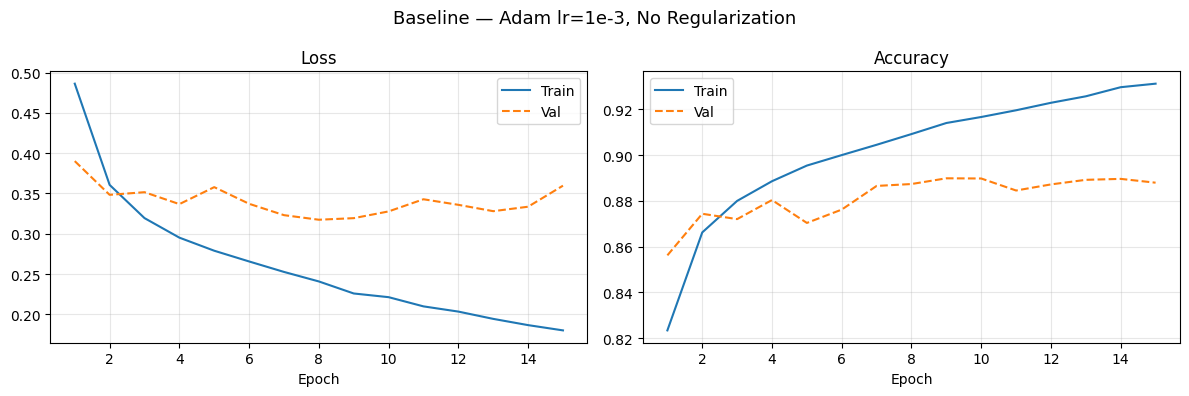

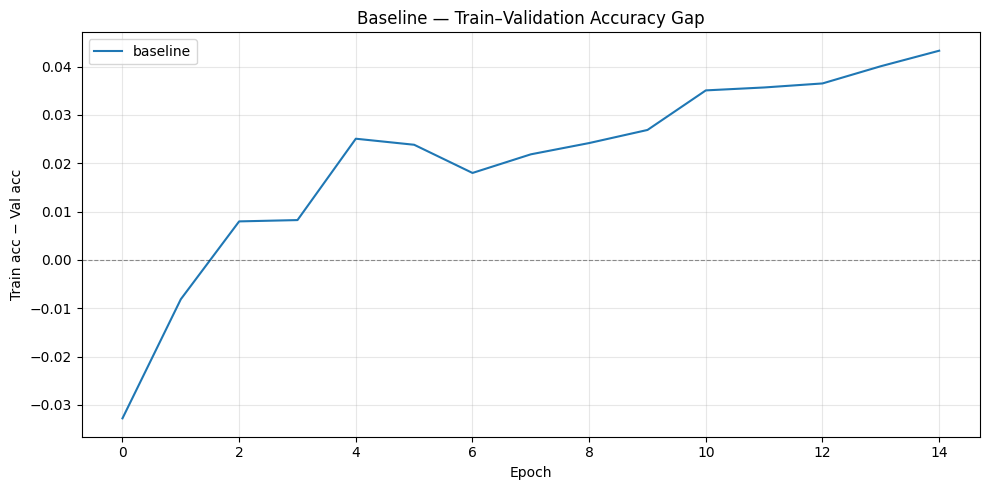

In [15]:
def plot_history(history, title='Training Curves'):
    '''Plot loss and accuracy curves from a history dict.'''
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], label='Train')
    ax1.plot(epochs, history['val_loss'],   label='Val', linestyle='--')
    ax1.set_title('Loss');     ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs, history['train_acc'], label='Train')
    ax2.plot(epochs, history['val_acc'],   label='Val', linestyle='--')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

def plot_gap(results, title='Train–Validation Accuracy Gap'):
    '''
    Plot the train-val accuracy gap (train_acc - val_acc) per epoch.
    '''
    plt.figure(figsize=(10, 5))
    for label, hist in results.items():
        gap = [t - v for t, v in zip(hist['train_acc'], hist['val_acc'])]
        plt.plot(gap, label=label)
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)  # zero-gap reference line
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Train acc − Val acc')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
plot_history(baseline_history, title='Baseline — Adam lr=1e-3, No Regularization')
plot_gap({'baseline': baseline_history}, title='Baseline — Train–Validation Accuracy Gap')

**Section 1 of your report** is based on what you just built and observed. Before moving on to Part 2, document:

- **Architecture**: layer dimensions and total parameter count
- **Loss function**: which one you chose and why it is appropriate for this task
- **Training configuration**: optimiser and key hyperparameters
- **Baseline results**: analyse the training curves — what does the train–validation accuracy gap tell you? (*Hint: compute the gap at the final epoch. A large or increasing train–validation gap can indicate overfitting.*)

---
## Part 2 — Experimental Analysis

This section guides you through the typical workflow of solving a supervised learning problem:

1. **Experiment 1 — Architecture**: find a model with sufficient capacity
2. **Experiment 2 — Optimiser & LR**: tune the training process for that model
3. **Experiment 3 — Regularisation**: address the overfitting observed in Experiment 1

**Protocol for each experiment:**
1. Read the experiment description carefully *before* running any code.
2. Complete the provided scaffold and run the experiment.
3. Generate the required comparison figures.
4. Fill in the **Results and Analysis** section with your observations and answers.

> **Implementation note**: `run_experiment()` instantiates and trains a freshly initialised model for each call. Because training is stochastic, numerical results may vary slightly between runs.

> **Pedagogical note**: Test accuracy is displayed in this TP for comparison and illustration. However, architecture and hyperparameter choices must be based on validation performance only. In a standard machine-learning workflow, the test set should be reserved for the final evaluation.

In [16]:
# ── Helper functions (provided — read before using) ───────────────────────────

def run_experiment(
    hidden_sizes=[256, 128],
    dropout_rate=0.0,
    use_batchnorm=False,
    optimizer='adam',    # 'adam' or 'sgd'
    lr=1e-3,
    weight_decay=0.0,
    momentum=0.0,        # for SGD with momentum only
    num_epochs=15,
    tag=''
):
    '''
    Train a fresh MLP and return its history + test accuracy.

    Args:
        hidden_sizes  : list of hidden layer widths, e.g. [256, 128]
        dropout_rate  : Dropout probability (0 = disabled)
        use_batchnorm : whether to insert BatchNorm1d after each Linear
        optimizer     : 'adam' or 'sgd'
        lr            : learning rate
        weight_decay  : L2 regularisation coefficient
        momentum      : SGD momentum (ignored for Adam)
        num_epochs    : number of training epochs
        tag           : label printed in the console

    Returns:
        hist     : dict with train_loss / val_loss / train_acc / val_acc (one value per epoch)
        test_acc : final accuracy on the held-out test set
    '''
    # Create a fresh, untrained model for this experiment
    model = MLP(hidden_sizes=hidden_sizes,
                dropout_rate=dropout_rate,
                use_batchnorm=use_batchnorm).to(device)

    # Create the optimiser
    if optimizer == 'adam':
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer == 'sgd':
        opt = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError(f"optimizer must be 'adam' or 'sgd', got {optimizer!r}")

    crit = nn.CrossEntropyLoss()
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print()
    print('-' * 50)
    print(f'  {tag}')
    print('-' * 50)

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, crit, opt)
        va_loss, va_acc = evaluate(model, val_loader, crit)
        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(va_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_acc'].append(va_acc)
        print(f'  Epoch {epoch:>2}: train={tr_acc:.2%}  val={va_acc:.2%}')

    _, test_acc = evaluate(model, test_loader, crit)
    print(f'  Test accuracy: {test_acc:.2%}')
    return hist, test_acc


def plot_comparison(results, metric='val_acc', title='Comparison'):
    '''Overlay multiple experiment runs on one plot.'''
    plt.figure(figsize=(10, 5))
    for label, hist in results.items():
        plt.plot(hist[metric], label=label)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_gap(results, title='Train–Validation Accuracy Gap'):
    '''
    Plot the train-val accuracy gap (train_acc - val_acc) per epoch.
    '''
    plt.figure(figsize=(10, 5))
    for label, hist in results.items():
        gap = [t - v for t, v in zip(hist['train_acc'], hist['val_acc'])]
        plt.plot(gap, label=label)
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Train acc − Val acc')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Experiment 1 — Model Architecture
**Objective**: Identify how model capacity affects learning — both in terms of final generalisation performance and convergence speed. In practice, architecture selection comes first: a model that is too small cannot learn the task (**underfitting**), while one that is too large memorises training-specific patterns (**overfitting**). The goal is to find the capacity sweet spot.

**Setting**: Adam `lr=1e-3`, no regularisation, **15 epochs**. Vary `hidden_sizes`:

| Config | hidden_sizes | Approx. params |
|--------|-------------|----------------|
| Micro | `[4]` | ~3k |
| Small | `[64]` | ~51k |
| Baseline | `[256, 128]` | ~235k |
| Large | `[512, 256]` | ~537k |

**What to observe**:
1. **`plot_gap`**: does the train–validation accuracy gap grow monotonically with the increase of model size?
2. **`plot_comparison(train_acc)`**: does a larger model converge faster in early epochs?
3. **`plot_comparison(val_acc)`**: where does val accuracy plateau — and what does that tell you about the benefit of adding more model capacity?



--------------------------------------------------
  Micro [4]
--------------------------------------------------
  Epoch  1: train=65.43%  val=74.65%
  Epoch  2: train=76.54%  val=76.75%
  Epoch  3: train=77.50%  val=77.55%
  Epoch  4: train=78.52%  val=78.72%
  Epoch  5: train=80.37%  val=79.77%
  Epoch  6: train=81.42%  val=80.70%
  Epoch  7: train=81.72%  val=81.53%
  Epoch  8: train=82.18%  val=80.96%
  Epoch  9: train=82.23%  val=81.79%
  Epoch 10: train=82.51%  val=81.86%
  Epoch 11: train=82.43%  val=81.83%
  Epoch 12: train=82.45%  val=81.43%
  Epoch 13: train=82.74%  val=81.83%
  Epoch 14: train=82.89%  val=82.32%
  Epoch 15: train=83.02%  val=82.00%
  Test accuracy: 81.27%

--------------------------------------------------
  Small [64]
--------------------------------------------------
  Epoch  1: train=82.11%  val=84.16%
  Epoch  2: train=86.02%  val=86.48%
  Epoch  3: train=87.22%  val=87.24%
  Epoch  4: train=88.25%  val=87.43%
  Epoch  5: train=88.89%  val=87.44%
  Epo

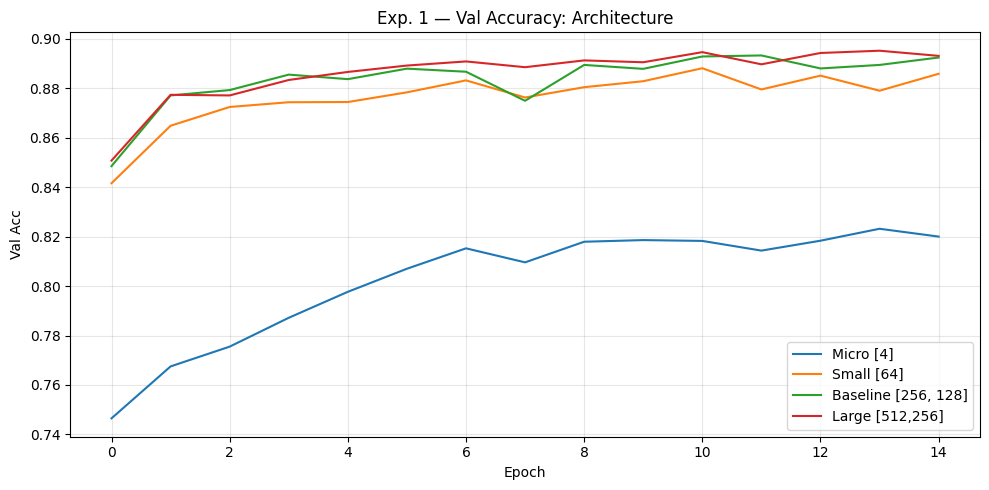

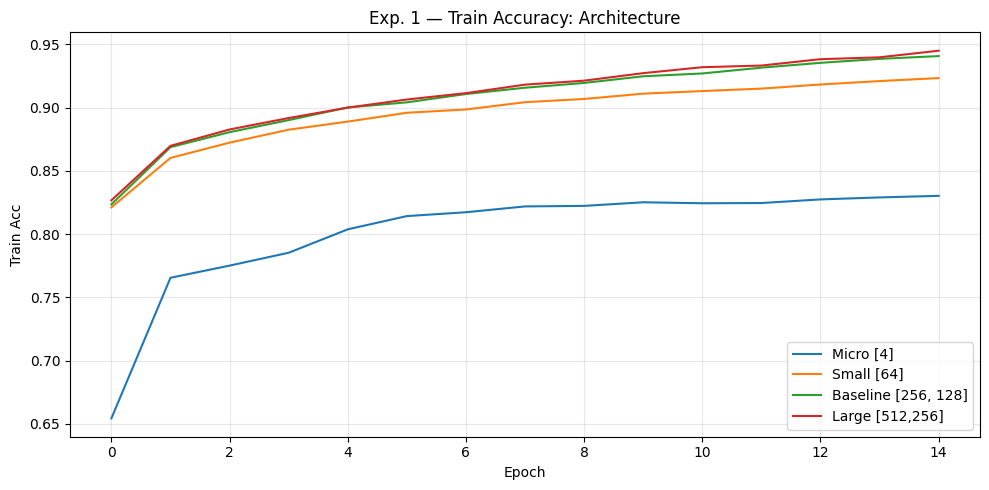

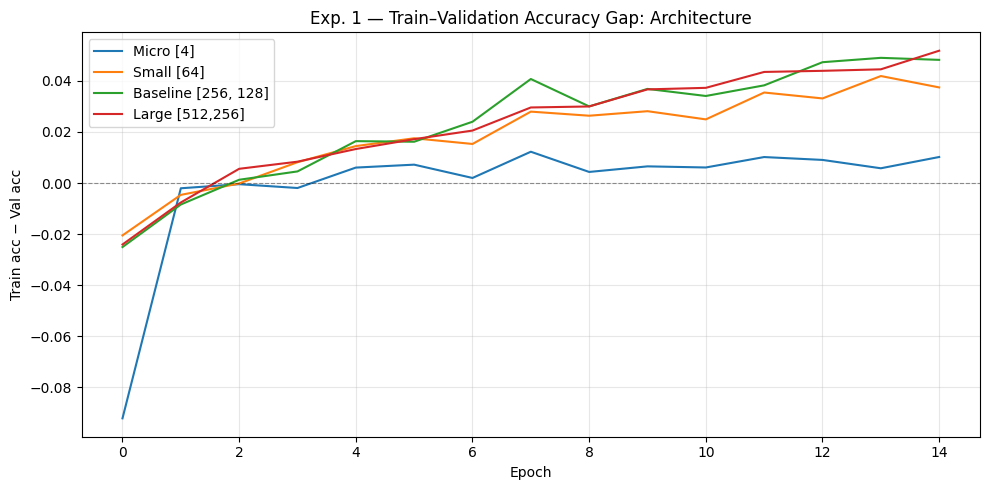

In [17]:
# ── Experiment 1  Model Architecture ─────────────────────────────────────────
exp_1 = {}

# TODO: run the 4 configurations — start with extremes, then fill in the middle

# Example — Micro [4]:
hist_micro, _ = run_experiment(
    hidden_sizes=[4],
    optimizer='adam',
    lr=1e-3,
    num_epochs=15,
    tag='Micro [4]'
)
exp_1['Micro [4]'] = hist_micro

# TODO: Small [64], Baseline [256,128], Large [512,256]

hist_micro, _ = run_experiment(
    hidden_sizes=[64],
    optimizer='adam',
    lr=1e-3,
    num_epochs=15,
    tag='Small [64]'
)
exp_1['Small [64]'] = hist_micro

hist_micro, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='adam',
    lr=1e-3,
    num_epochs=15,
    tag='Baseline [256, 128]'
)
exp_1['Baseline [256, 128]'] = hist_micro

hist_micro, _ = run_experiment(
    hidden_sizes=[512,256],
    optimizer='adam',
    lr=1e-3,
    num_epochs=15,
    tag='Large [512,256]'
)
exp_1['Large [512,256]'] = hist_micro

plot_comparison(exp_1, metric='val_acc',   title='Exp. 1 — Val Accuracy: Architecture')
plot_comparison(exp_1, metric='train_acc', title='Exp. 1 — Train Accuracy: Architecture')
plot_gap(exp_1, title='Exp. 1 — Train–Validation Accuracy Gap: Architecture')

**Results and Analysis** *(complete after running)*

Fill in the table from your results, then answer each observation:

| Config | Train acc (ep15) | Val acc (ep15) | Gap | Test acc |
|--------|-----------------|----------------|-----|----------|
| Micro [4] | 83.02 % | 82.00 % | 1.02 | 81.27 % |
| Small [64] | 92.33 % | 88.58 % | 3.75 | 88.10 % |
| Baseline [256, 128] | 94.06 % | 89.24 % | 4.82 | 88.63 % |
| Large [512, 256] | 94.49 % | 89.31 % | 5.18 | 88.75 % |

- **Underfitting**: Describe what you observe for Micro [4] in `train_acc` and `plot_gap`. Does a small gap always mean good generalisation? Why or why not?
- **Overfitting**: Which configurations show a clearly widening gap over 15 epochs? Describe the gap trajectory.
- **Val accuracy plateau**: At what capacity does validation accuracy begin to plateau? What does this suggest about the benefit of adding more model capacity under the current training setup?
- **Bias–variance trade-off**: Report the exact final-epoch gap for each configuration. Is the gap monotonically increasing with capacity?
- **Architecture selection**: Which architecture would you recommend? Justify your choice considering both val accuracy and gap — and note that Experiment 3 will address the overfitting you observed.


### Experiment 2 — Optimiser and Learning Rate

Having selected an architecture in Experiment 1, the next step is to ensure training is efficient.

This experiment is split into two connected sub-experiments:

| Sub-experiment | Objective |
|----------------|-----------|
| **2.A — Learning rate** | Show that SGD is highly sensitive to LR — motivating the need for adaptive optimisers |
| **2.B — Optimiser comparison** | Verify that Adam addresses SGD's LR sensitivity and converges faster |

#### 2.A — Learning Rate

**Objective**: Demonstrate that SGD's performance depends critically on learning rate — and why this is a problem in practice.

**Setting**: architecture `[256, 128]`, SGD (no momentum), no regularisation, 15 epochs.  
**Vary**: LR ∈ {1e-5, 1e-3, 0.1}

| LR | Expected behaviour |
|----|--------------------|
| `1e-5` | Near-random accuracy — updates too small to move weights meaningfully |
| `1e-3` | Slow convergence — learning, but far from optimal within 15 epochs |
| `0.1` | Near-optimal — fast, stable convergence |


--------------------------------------------------
  SGD lr=0.1
--------------------------------------------------
  Epoch  1: train=80.11%  val=85.22%
  Epoch  2: train=86.19%  val=85.44%
  Epoch  3: train=87.54%  val=87.58%
  Epoch  4: train=88.86%  val=88.08%
  Epoch  5: train=89.30%  val=88.37%
  Epoch  6: train=90.04%  val=88.27%
  Epoch  7: train=90.77%  val=88.49%
  Epoch  8: train=91.08%  val=87.78%
  Epoch  9: train=91.61%  val=89.14%
  Epoch 10: train=92.05%  val=87.81%
  Epoch 11: train=92.42%  val=89.12%
  Epoch 12: train=92.76%  val=89.08%
  Epoch 13: train=93.17%  val=89.17%
  Epoch 14: train=93.49%  val=88.52%
  Epoch 15: train=93.77%  val=89.11%
  Test accuracy: 88.50%

--------------------------------------------------
  SGD lr=1e-3
--------------------------------------------------
  Epoch  1: train=43.76%  val=54.31%
  Epoch  2: train=59.77%  val=65.99%
  Epoch  3: train=68.95%  val=70.62%
  Epoch  4: train=72.09%  val=72.09%
  Epoch  5: train=73.83%  val=74.01%
  E

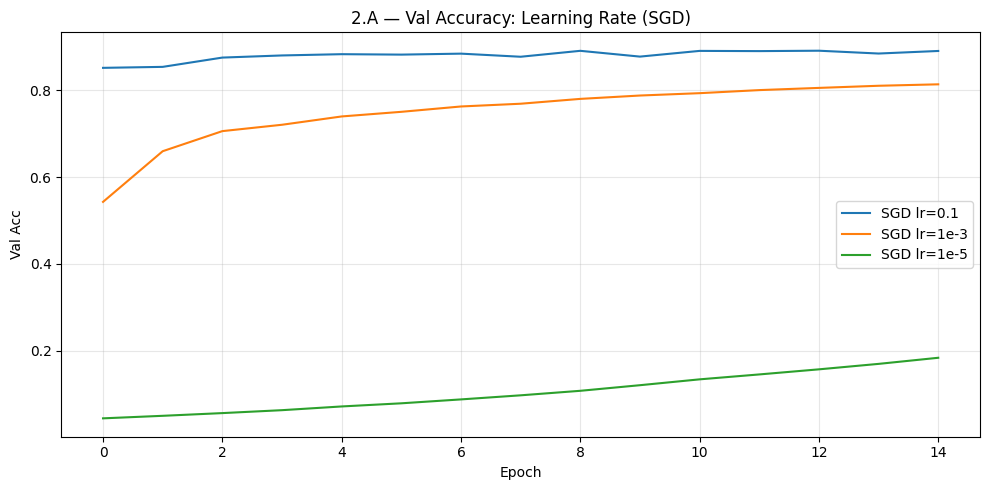

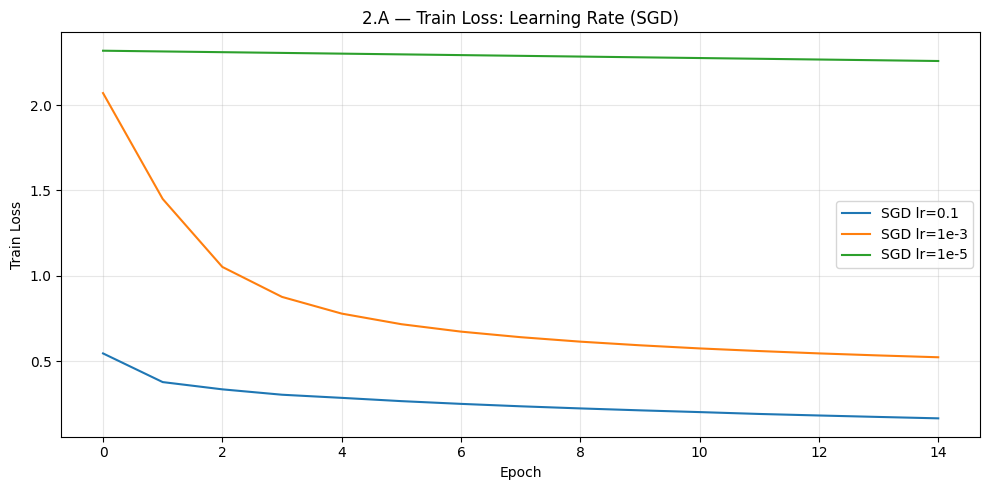

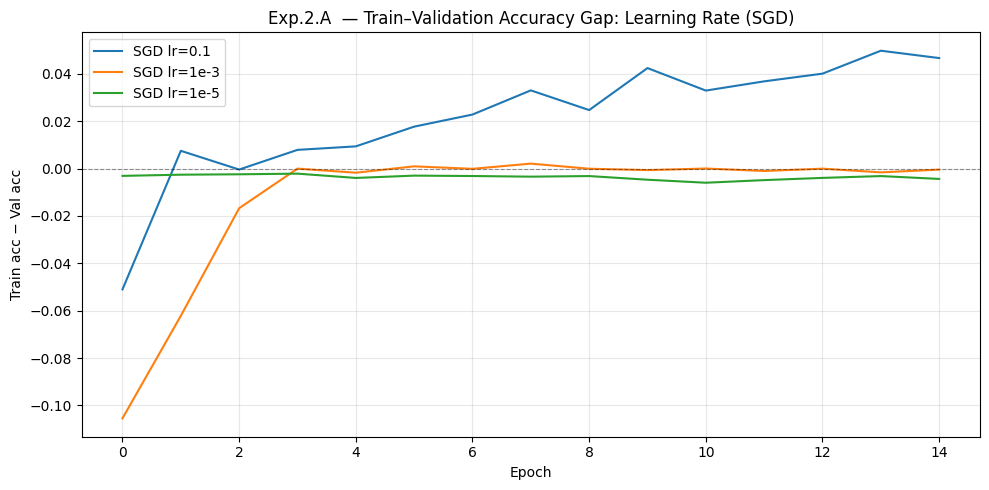

In [18]:
# ── 2.A  Learning Rate ────────────────────────────────────────────────────────
exp_2a = {}

# TODO: run SGD at lr=1e-5, lr=1e-3, lr=0.1

# Example — lr=0.1:
hist, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='sgd',
    lr=0.1,
    num_epochs=15,
    tag='SGD lr=0.1'
)
exp_2a['SGD lr=0.1'] = hist

# TODO: add SGD lr=1e-3 and lr=1e-5
hist, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='sgd',
    lr=1e-3,
    num_epochs=15,
    tag='SGD lr=1e-3'
)
exp_2a['SGD lr=1e-3'] = hist

hist, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='sgd',
    lr=1e-5,
    num_epochs=15,
    tag='SGD lr=1e-5'
)
exp_2a['SGD lr=1e-5'] = hist

plot_comparison(exp_2a, metric='val_acc',    title='2.A — Val Accuracy: Learning Rate (SGD)')
plot_comparison(exp_2a, metric='train_loss', title='2.A — Train Loss: Learning Rate (SGD)')
plot_gap(exp_2a, title='Exp.2.A  — Train–Validation Accuracy Gap: Learning Rate (SGD)')

**Results and Analysis** *(complete after running)*

Report the final val accuracy and test accuracy for each LR configuration, then answer the questions below.

- Describe the convergence behaviour for each LR. What happens to a model trained with lr=1e-5 after 15 epochs?
- Compare lr=1e-3 and lr=0.1: both converge, but how differently? What does this say about the cost of a suboptimal LR choice?


**Réponses**
| LR | Val acc (ep15) | Test acc |
|----|---------------|----------|
| 1e-5 | 18.36 % | 18.82 % |
| 1e-3 | 81.42 % | 80.30 % |
| 0.1 | 89.11 % | 88.50 % |


#### 2.B — Optimiser Comparison

**Objective**: Compare the convergence speed of SGD and Adam across the same range of learning rates — and determine whether Adam's adaptive mechanism provides a meaningful advantage.

**Setting**: architecture `[256, 128]`, no regularisation, **15 epochs**.

| Configuration | Optimiser | LR |
|---------------|-----------|-----|
| SGD — naive | SGD | `1e-3` |
| SGD — tuned | SGD | `0.1` |
| Adam — naive | Adam | `1e-3` |
| Adam lr=0.1 | Adam | `0.1` |
| Adam lr=1e-5 | Adam | `1e-5` |

**Focus on convergence speed** — how many epochs does each configuration need to reach 80%? 85%? 88% val accuracy?


--------------------------------------------------
  SGD lr=1e-3 (naive)
--------------------------------------------------
  Epoch  1: train=43.07%  val=63.49%
  Epoch  2: train=66.14%  val=67.80%
  Epoch  3: train=70.05%  val=71.30%
  Epoch  4: train=72.86%  val=72.85%
  Epoch  5: train=74.33%  val=74.26%
  Epoch  6: train=75.60%  val=75.65%
  Epoch  7: train=76.63%  val=76.53%
  Epoch  8: train=77.51%  val=77.53%
  Epoch  9: train=78.22%  val=78.44%
  Epoch 10: train=78.96%  val=79.23%
  Epoch 11: train=79.77%  val=79.85%
  Epoch 12: train=80.36%  val=80.49%
  Epoch 13: train=80.91%  val=80.78%
  Epoch 14: train=81.30%  val=81.28%
  Epoch 15: train=81.65%  val=81.67%
  Test accuracy: 80.68%

--------------------------------------------------
  Adam lr=1e-3 (naive)
--------------------------------------------------
  Epoch  1: train=82.42%  val=85.53%
  Epoch  2: train=86.87%  val=86.51%
  Epoch  3: train=88.33%  val=87.98%
  Epoch  4: train=89.25%  val=87.52%
  Epoch  5: train=89.7

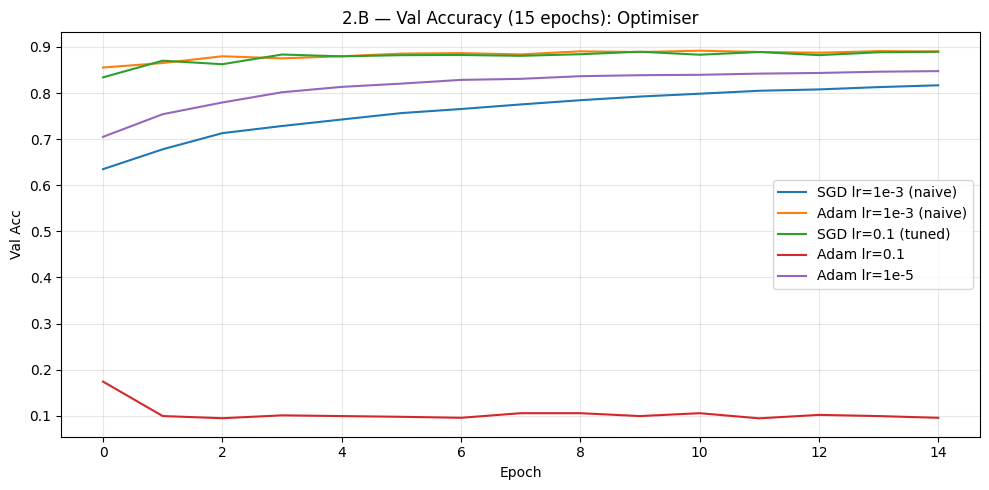

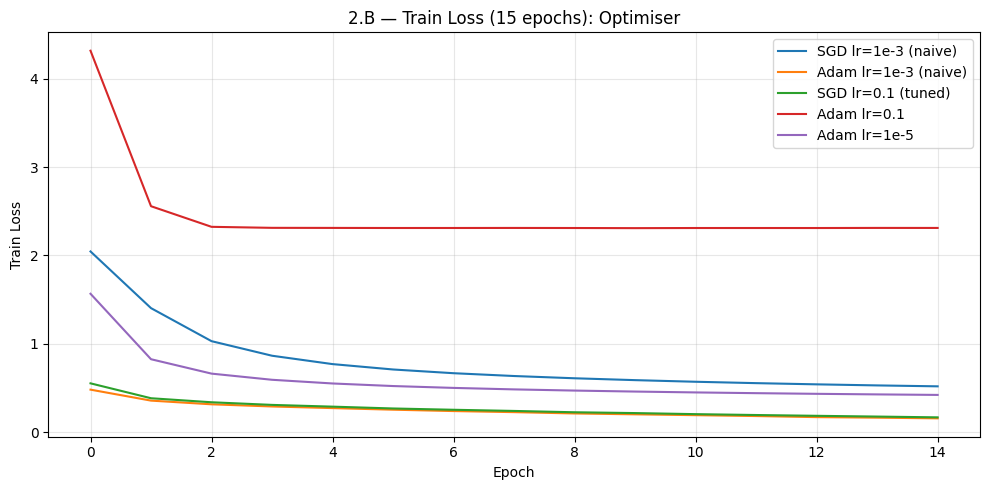

In [19]:
# ── 2.B  Optimiser Comparison ─────────────────────────────────────────────────
# Compare SGD and Adam across the same LR values to show Adam's robustness
exp_2b = {}

# TODO: run the 5 configurations

# Example — SGD naive (lr=1e-3, no prior search):
hist, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='sgd',
    lr=1e-3,
    num_epochs=15,
    tag='SGD lr=1e-3 (naive)'
)
exp_2b['SGD lr=1e-3 (naive)'] = hist

# TODO: Adam lr=1e-3 (naive), SGD lr=0.1 (tuned), Adam lr=0.1, Adam lr=1e-5
hist, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='adam',
    lr=1e-3,
    num_epochs=15,
    tag='Adam lr=1e-3 (naive)'
)
exp_2b['Adam lr=1e-3 (naive)'] = hist

hist, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='sgd',
    lr=0.1,
    num_epochs=15,
    tag='SGD lr=0.1 (tuned)'
)
exp_2b['SGD lr=0.1 (tuned)'] = hist

hist, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='adam',
    lr=0.1,
    num_epochs=15,
    tag='Adam lr=0.1'
)
exp_2b['Adam lr=0.1'] = hist

hist, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='adam',
    lr=1e-5,
    num_epochs=15,
    tag='Adam lr=1e-5'
)
exp_2b['Adam lr=1e-5'] = hist


plot_comparison(exp_2b, metric='val_acc',    title='2.B — Val Accuracy (15 epochs): Optimiser')
plot_comparison(exp_2b, metric='train_loss', title='2.B — Train Loss (15 epochs): Optimiser')

**Results and Analysis**

Fill in the convergence table from your results, then answer the questions below.

| Configuration | Learning Rate | Best val acc | Epochs to reach best |
|---------------|---------------|-------------|---------------------|
| SGD best | 0.1 | 88.96 % | 10 |
| Adam best | 1e-3 | 89.18 % | 11 |

- At which tested learning rate does each optimiser achieve its best validation accuracy?
- At each optimiser's best tested learning rate, compare their convergence speed. Does Adam converge noticeably faster than SGD? Relate your observation to Adam's adaptive parameter updates.
- At the same learning rate (lr=1e-3), compare the learning dynamics of SGD and Adam. What does this show about using the same global learning rate for different optimisers?



### Experiment 3 — Regularisation

**Objective**: In Experiment 1 you observed that `[256, 128]` shows a train–validation accuracy gap of ~4–5%. This experiment investigates techniques to reduce that gap without sacrificing validation accuracy.

**Setting**: architecture `[256, 128]`, Adam `lr=1e-3`, **20 epochs** (longer run makes overfitting dynamics clearly visible).

| Configuration | Parameters |
|---------------|-----------|
| Baseline | `dropout_rate=0.0, use_batchnorm=False` |
| Dropout | `dropout_rate=0.3` |
| Weight decay | `weight_decay=1e-3` in Adam |
| Dropout + BN | both enabled |

Plot `val_acc`, `train_acc`, and **`plot_gap`** — the gap plot directly shows which technique reduces overfitting most effectively.

> **Reminder**: A widening train–validation gap can indicate overfitting. Another common sign is that training performance continues to improve while validation performance stagnates or deteriorates.


--------------------------------------------------
  No regularisation
--------------------------------------------------
  Epoch  1: train=82.19%  val=86.33%
  Epoch  2: train=86.84%  val=87.62%
  Epoch  3: train=88.19%  val=87.94%
  Epoch  4: train=89.09%  val=87.83%
  Epoch  5: train=89.78%  val=88.70%
  Epoch  6: train=90.34%  val=87.77%
  Epoch  7: train=90.87%  val=88.79%
  Epoch  8: train=91.28%  val=87.73%
  Epoch  9: train=91.99%  val=87.95%
  Epoch 10: train=92.32%  val=89.16%
  Epoch 11: train=92.81%  val=89.34%
  Epoch 12: train=92.97%  val=88.73%
  Epoch 13: train=93.48%  val=88.81%
  Epoch 14: train=93.69%  val=89.71%
  Epoch 15: train=94.08%  val=89.03%
  Epoch 16: train=94.36%  val=88.83%
  Epoch 17: train=94.49%  val=89.03%
  Epoch 18: train=94.95%  val=89.57%
  Epoch 19: train=95.14%  val=89.05%
  Epoch 20: train=95.28%  val=89.34%
  Test accuracy: 88.95%

--------------------------------------------------
  Dropout
--------------------------------------------------


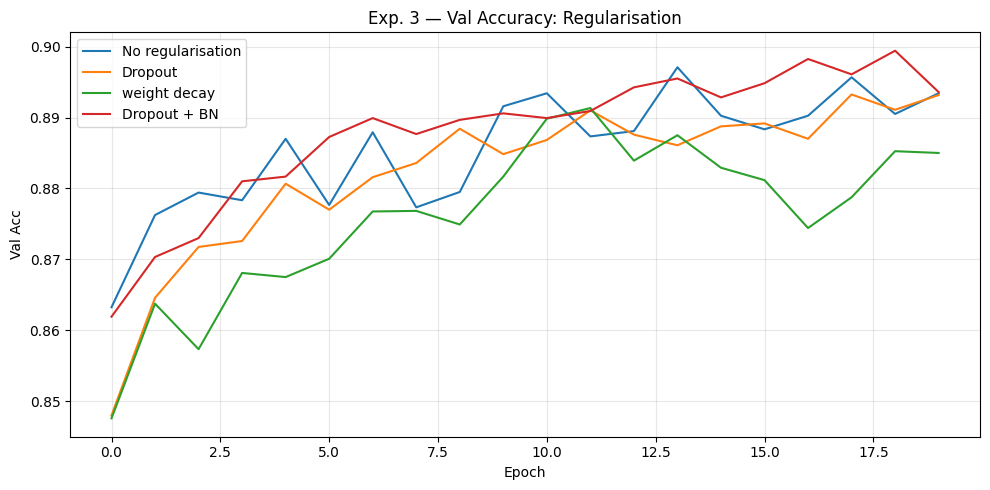

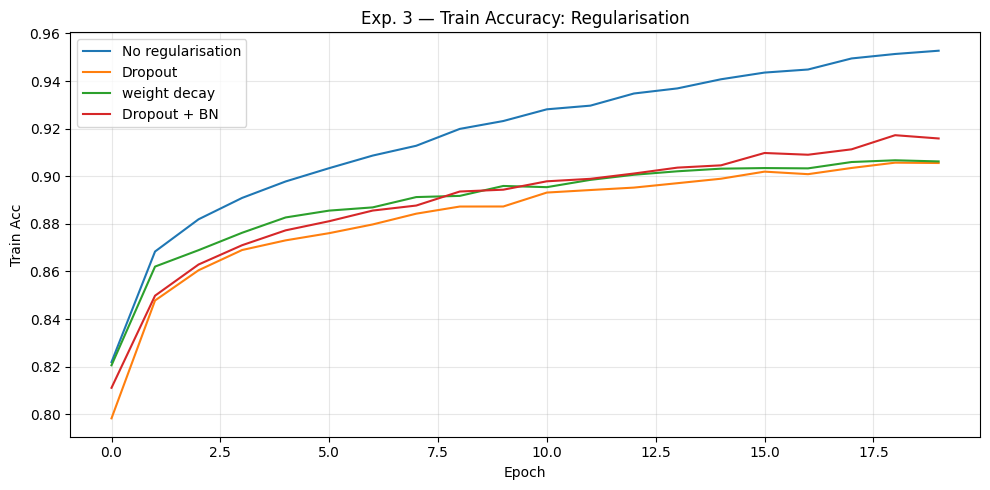

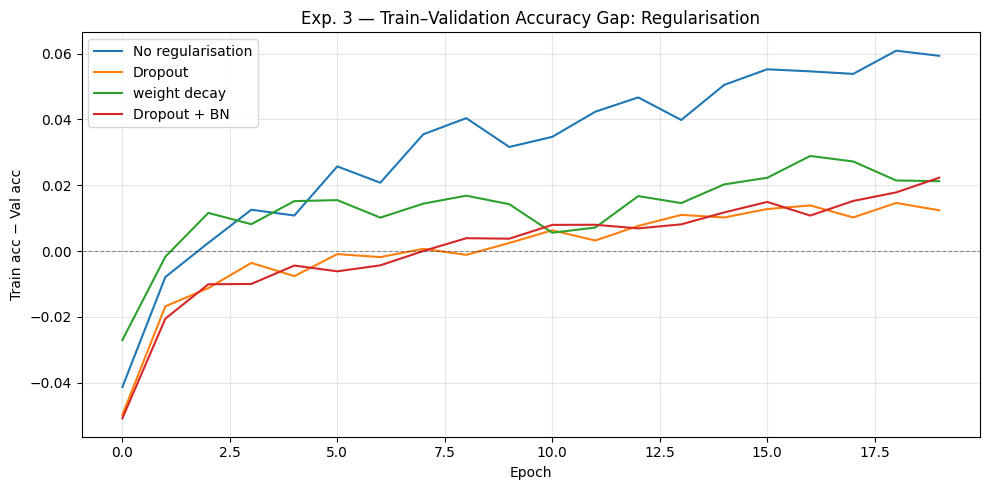

In [20]:
# ── Experiment 3  Regularisation ─────────────────────────────────────────────
exp_3 = {}
N_EPOCHS = 20

# ── Baseline: no regularisation ───────────────────────────────────────────────
hist_base, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='adam',
    lr=1e-3,
    num_epochs=N_EPOCHS,
    tag='No regularisation'
)
exp_3['No regularisation'] = hist_base

# ── Dropout ───────────────────────────────────────────────────────────────────
# TODO: dropout_rate=0.3
hist_base, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='adam',
    lr=1e-3,
    num_epochs=N_EPOCHS,
    dropout_rate=0.3,
    tag='Dropout'
)
exp_3['Dropout'] = hist_base

# ── Weight decay ─────────────────────────────────────────────────────────────
# TODO: weight_decay=1e-3
hist_base, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='adam',
    lr=1e-3,
    num_epochs=N_EPOCHS,
    weight_decay=1e-3,
    tag='Weight decay'
)
exp_3['weight decay'] = hist_base

# ── Dropout + BN (optional) ──────────────────────────────────────────────────
# TODO (optional): dropout_rate=0.3, use_batchnorm=True
hist_base, _ = run_experiment(
    hidden_sizes=[256, 128],
    optimizer='adam',
    lr=1e-3,
    num_epochs=N_EPOCHS,
    dropout_rate=0.3,
    use_batchnorm=True,
    tag='Dropout + BN'
)
exp_3['Dropout + BN'] = hist_base

plot_comparison(exp_3, metric='val_acc',   title='Exp. 3 — Val Accuracy: Regularisation')
plot_comparison(exp_3, metric='train_acc', title='Exp. 3 — Train Accuracy: Regularisation')
plot_gap(exp_3, title='Exp. 3 — Train–Validation Accuracy Gap: Regularisation')

**Results and Analysis** *(complete after running)*

Report train accuracy, validation accuracy, and train–validation accuracy gap for each configuration in a table and answer the questions below:

| Configuration | Train (ep20) | Val (ep20) | Gap | Test acc | Epoch of best val acc |
|---------------|-------------|-----------|-----|----------|------------------|
| No regularisation | 95.28 % | 89.34 % | 5.94 | 88.95 % | 14 |
| Dropout 0.3 | 90.56 % | 89.32 % | 1.24 | 88.63 % | 18 |
| Weight decay 1e-3 | 90.62 % | 88.50 % | 2.12 | 87.94 % | 12 |
| Dropout + BN | 91.59 % | 89.36 % | 2.23 | 89.20 % | 19 |

- Dropout and weight decay both can reduce overfitting but through different mechanisms. Explain each. Which configuration shows the smallest train–validation accuracy gap and highest validation accuracy? 
- Looking at the *Epoch of best val acc* column: how does adding regularisation affect the number of epochs the model needs to reach its best val accuracy? What does this tell you about the relationship between regularisation and training dynamics?
- Play with the hyperparameters, and document your observations. (Optional)